# Fleet Maintenance - RUL Prediction
## Exploratory Data Analysis & Model Development

**Goal:** Predict Remaining Useful Life (RUL) of turbofan engines using NASA C-MAPSS dataset

**Dataset:** Simulated turbofan engine degradation data with 21 sensors

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
import shap

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', 30)
%matplotlib inline

## 2. Load the Data

The C-MAPSS dataset contains:
- **engine_id**: Unique to engine
- **cycle**: Flight Cycle
- **setting_1, 2, 3**: Operational settings
- **sensor_1 to sensor_21**: Sensor measurements

In [2]:
# Column names for the dataset
columns = ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3']
columns += [f'sensor_{i}' for i in range(1, 22)]

# Load training data 
# Simplest data set Data Set: FD001 Train trjectories: 100 Test trajectories: 100 Conditions: ONE (Sea Level) Fault Modes: ONE (HPC Degradation)
data_path = '../data/'
df = pd.read_csv(data_path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)
test = pd.read_csv((data_path + 'test_FD001.txt'), sep=r'\s+', header=None, names=columns)
y_test = pd.read_csv((data_path + 'RUL_FD001.txt'), sep=r'\s+', header=None, names=['rul']).iloc[:,0]

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Calculate RUL (Target Variable)

RUL = Remaining cycles until engine failure

In [3]:
# Calculate max cycle per engine (cycle when it fails)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge and calculate RUL
df = df.merge(max_cycles, on='engine_id')
df['rul'] = df['max_cycle'] - df['cycle']
df = df.drop('max_cycle', axis=1)

print(f"RUL range: {df['rul'].min()} to {df['rul'].max()}")
df[['engine_id', 'cycle', 'rul']].head(10)

RUL range: 0 to 361


,engine_id,cycle,rul
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


## 4. Exploratory Data Analysis

### 4.1 Basic Statistics

In [4]:
df.describe()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


In [5]:
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
df[sensor_names].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


### 4.2 RUL Distribution

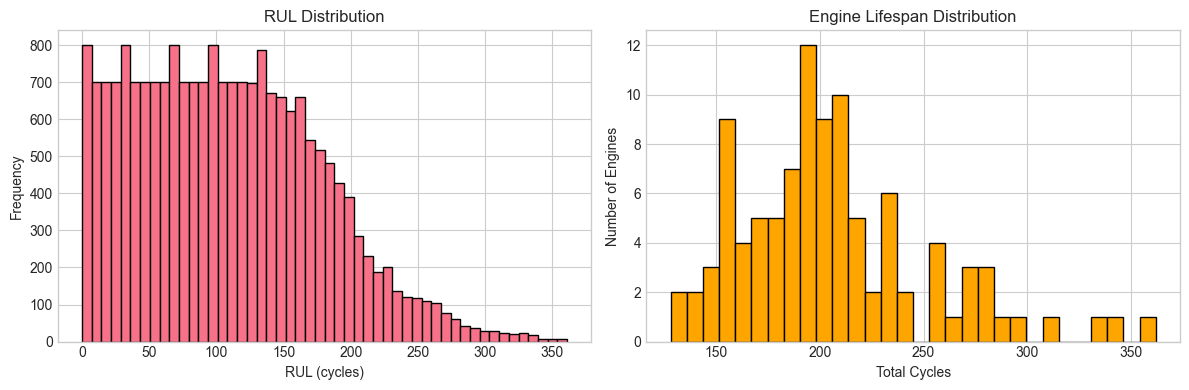

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RUL distribution
axes[0].hist(df['rul'], bins=50, edgecolor='black')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('RUL Distribution')

# Engine lifespan distribution
lifespans = df.groupby('engine_id')['cycle'].max()
axes[1].hist(lifespans, bins=30, edgecolor='black', color='orange')
axes[1].set_xlabel('Total Cycles')
axes[1].set_ylabel('Number of Engines')
axes[1].set_title('Engine Lifespan Distribution')

plt.tight_layout()
plt.show()

The engine lifespan distribution (orange) is approximately bell-shaped and right-skewed, with most engines failing between 150 and 250 cycles and a peak around 200 cycles. A small number of outlier engines survive beyond 300 cycles, pulling the tail to the right.
The RUL distribution (pink) is a direct consequence of this: because each engine contributes one row per cycle counting down from its maximum lifespan to 0, engines with longer lives generate more high-RUL data points. However, since most engines cluster around 200 cycles, the dataset accumulates far more rows in the low-to-mid RUL range than at high RUL values, hence the declining frequency toward the right tail.

This imbalance has a practical implication: the model will be trained on proportionally more examples of engines close to failure than engines in early healthy operation. This is acceptable given our goal, accurately predicting imminent failure is more critical than estimating RUL when an engine has hundreds of cycles remaining.

### 4.3 Sensor Readings Over Time

Let's see how sensors change as an engine degrades

In [7]:
# How many engines? How many cycles per engine?
print(f"Number of engines: {df['engine_id'].nunique()}")
print(f"\nCycles per engine:")
df.groupby('engine_id')['cycle'].max().describe()

Number of engines: 100

Cycles per engine:


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Several sensors show near-zero standard deviation indicating they remain constant across all operating cycles and carry no predictive signal. These will be dropped before modelling. The rest of the sensors show a high variance and are worth examining for degradation trends.

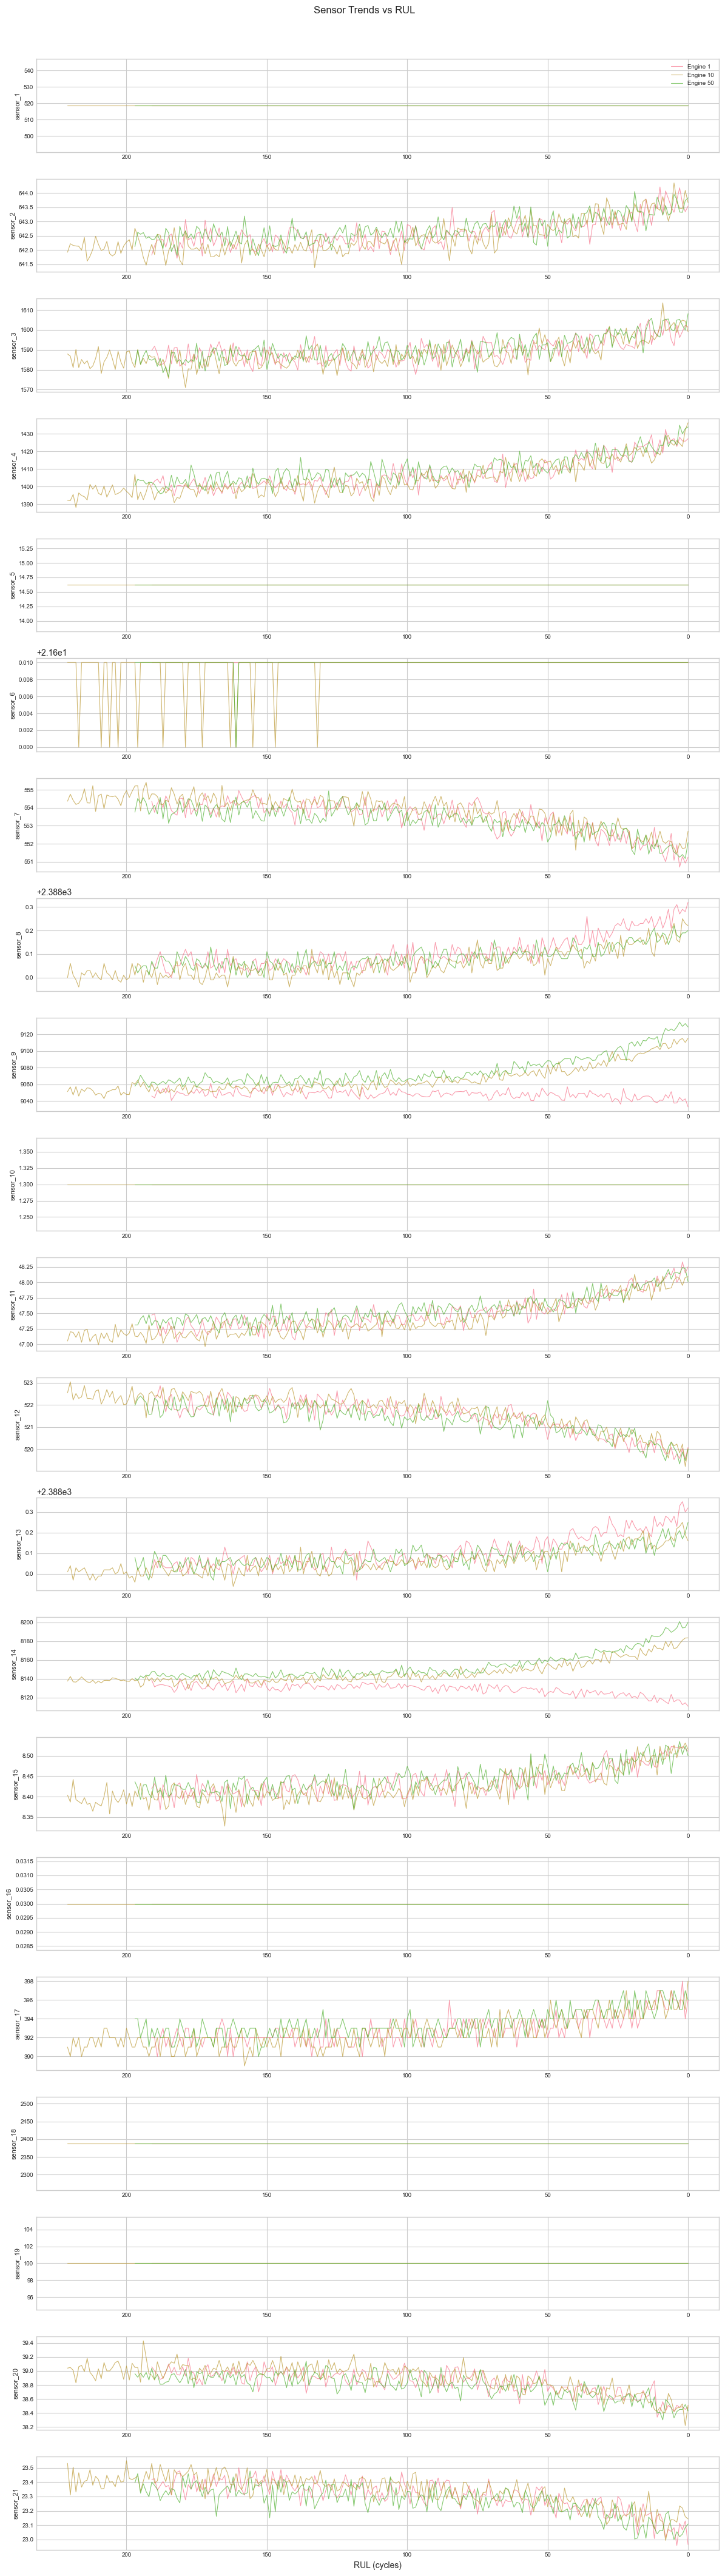

In [8]:
def plot_all_sensor_trends(df, sample_engines, sensors_to_plot):
    n = len(sensors_to_plot)
    fig, axes = plt.subplots(n, 1, figsize=(12, n * 2), squeeze=False)
    
    for i, sensor in enumerate(sensors_to_plot):
        for engine in sample_engines:
            engine_data = df[df['engine_id'] == engine]
            axes[i][0].plot(engine_data['rul'], engine_data[sensor], 
                         label=f'Engine {engine}', alpha=0.7, linewidth=0.8)
        axes[i][0].set_ylabel(sensor, fontsize=8)
        axes[i][0].invert_xaxis()
        axes[i][0].tick_params(labelsize=7)
        if i == 0:
            axes[i][0].legend(loc='upper right', fontsize=7)
    
    axes[-1][0].set_xlabel('RUL (cycles)')
    plt.suptitle('Sensor Trends vs RUL', y=1.01)
    plt.tight_layout()
    plt.show()

sample_engines = [1, 10, 50]
plot_all_sensor_trends(df, sample_engines, sensor_names)

**Sensor Trend Analysis vs Remaining Useful Life**

To validate the variance-based feature selection, each sensor's readings were plotted aligned by RUL for three sample engines (1, 10, 50). Aligning by RUL allows us to directly compare degradation patterns across engines, anchoring all trajectories to the same reference point: failure at RUL=0.
Sensors to be dropped (no degradation signal):
Sensors 1, 5, 6, 10, 16, 18, and 19 show flat, near-constant readings across the entire engine lifecycle with no directional trend as RUL approaches zero. These carry no predictive value and are removed from the feature set.

Sensors retained:
The remaining sensors show a consistent directional trend as RUL approaches zero. Notably, sensors 2, 3, and 4 show a strong and early upward trend, providing a clean degradation signal across all three engines. Other sensors such as 9 and 14 appear noisier during the healthy phase but develop a clear directional trend in the final 50–75 cycles before failure.

Since the C-MAPSS dataset anonymises all sensor labels, we cannot reason about the physical interpretation of these trends. However, the direction of change is irrelevant for modelling purposes. What matters is that the movement is consistent across engines and concentrated in the degradation region.

### 4.4 Correlation Analysis

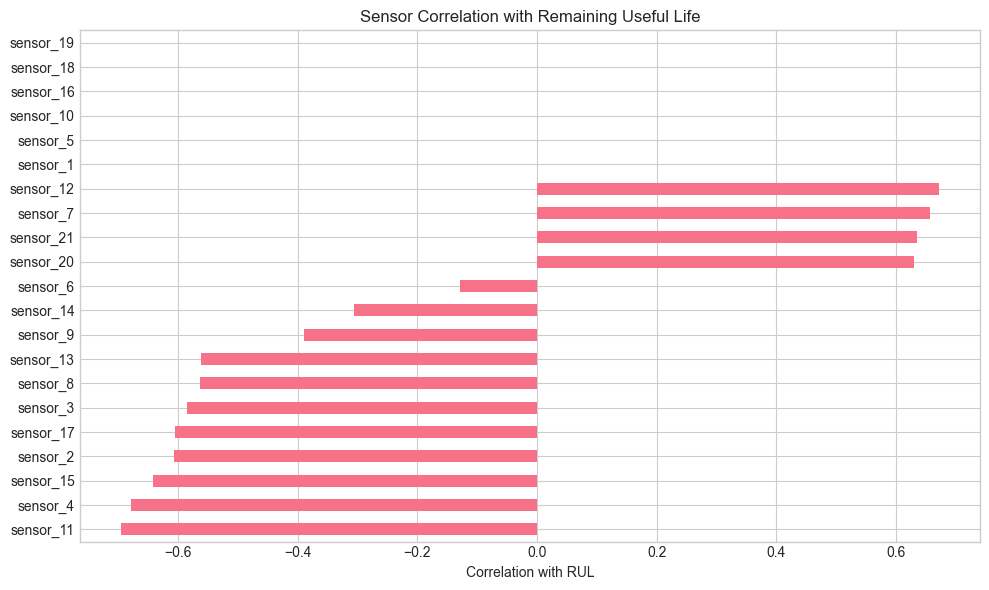

In [9]:
# Correlation with RUL
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
correlations = df[sensor_cols + ['rul']].corr()['rul'].drop('rul').sort_values()

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh')
plt.xlabel('Correlation with RUL')
plt.title('Sensor Correlation with Remaining Useful Life')
plt.tight_layout()
plt.show()

**Sensor Correlation with RUL**

Sensors 11, 4, 15, 2, 17, and 3 show the strongest negative correlations (around -0.6 to -0.7), meaning their values consistently increase as the engine approaches failure. Conversely, sensors 12, 7, 21, and 20 show strong positive correlations (~0.6), meaning they decrease toward failure. 

Sensors 1, 5, 6, 10, 16, 18, and 19 show correlations near zero, confirming our earlier visual assessment — these sensors do not vary with RUL and are excluded from the feature set.

Note that Pearson correlation only captures linear relationships. A sensor with moderate correlation here may still carry nonlinear predictive signal that tree-based models like XGBoost or Random Forest can exploit. Correlation is therefore used as a supporting metric, not the sole criterion for feature selection.

Sensors with |correlation| > 0.1: ['sensor_11', 'sensor_4', 'sensor_15', 'sensor_2', 'sensor_17', 'sensor_3', 'sensor_8', 'sensor_13', 'sensor_9', 'sensor_14', 'sensor_6', 'sensor_20', 'sensor_21', 'sensor_7', 'sensor_12']


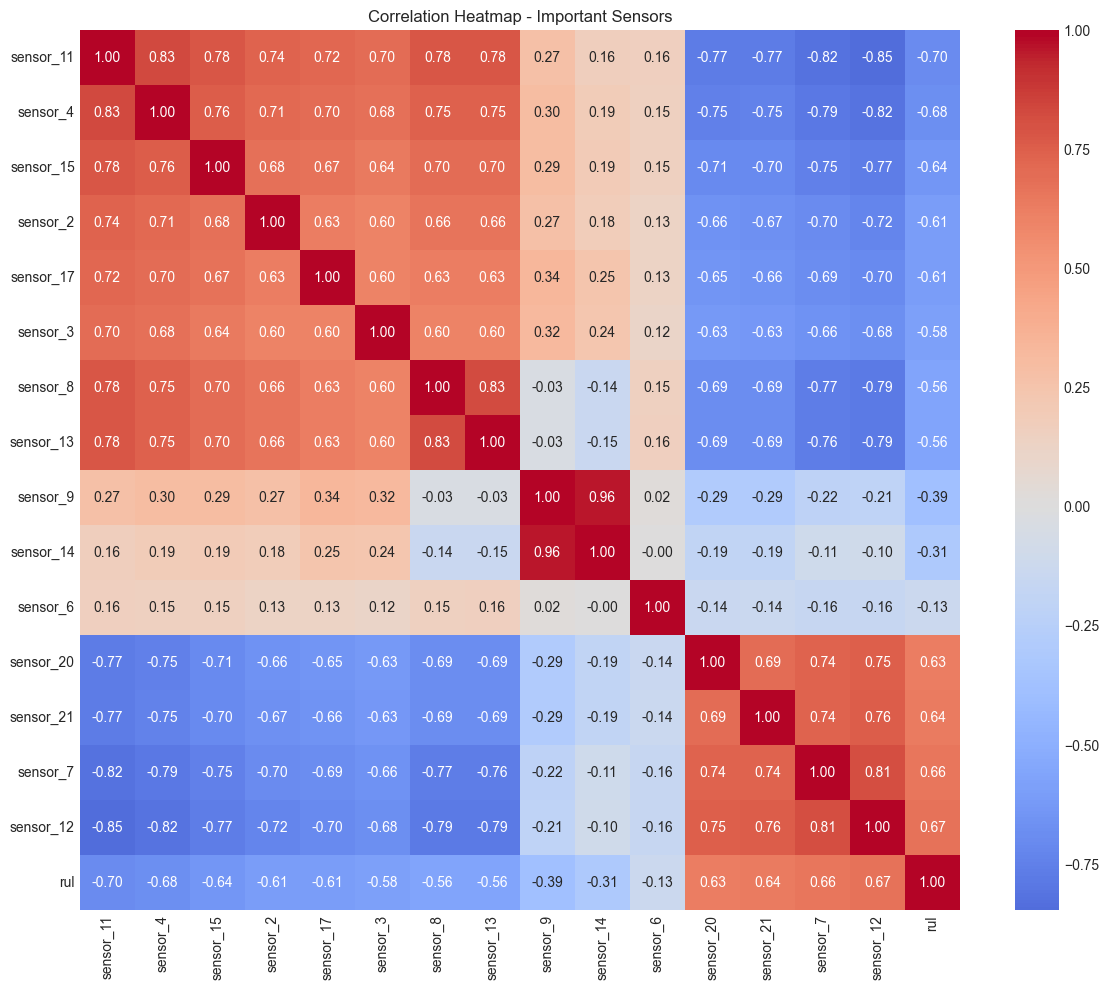

In [10]:
# Full correlation heatmap (subset of sensors)
important_sensors = correlations[abs(correlations) > 0.1].index.tolist()
print(f"Sensors with |correlation| > 0.1: {important_sensors}")

plt.figure(figsize=(12, 10))
sns.heatmap(df[important_sensors + ['rul']].corr(), 
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Important Sensors')
plt.tight_layout()
plt.show()

### 4.5 Sensors with No Variance

Some sensors might be constant - we should identify and potentially remove them

In [11]:
# Check variance of each sensor
sensor_variance = df[sensor_cols].var().sort_values()
# Identify low-variance sensors
low_var_sensors = sensor_variance[sensor_variance < 0.001].index.tolist()
print(f"\nLow variance sensors (consider removing): {low_var_sensors}")


Low variance sensors (consider removing): ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5', 'sensor_6']


---

## 5. Baseline Model - Linear Regression

In [12]:
# Selected sensors
feature_cols = [col for col in df.columns if col.startswith('sensor_')]
feature_cols = [col for col in feature_cols if col not in low_var_sensors]  # Remove low variance

X = df[feature_cols]
y = df['rul']
t = test.groupby('engine_id').last().reset_index()
X_test = t[feature_cols]

In [13]:
def evaluate_model(model, X, y, label='train'):
    """Evaluate an already-fitted model"""
    y_pred = model.predict(X)
    
    return {
        f'RMSE {label}': round(float(np.sqrt(mean_squared_error(y, y_pred))), 2),
        f'MAE {label}': round(float(mean_absolute_error(y, y_pred)), 2),
        f'R2 {label}': round(float(r2_score(y, y_pred)), 4)
    }

model = LinearRegression()
model.fit(X, y)

train_results = evaluate_model(model, X, y, label='train')
test_results = evaluate_model(model, X_test, y_test, label='test')
print("Train:", train_results)
print("Test: ", test_results)

Train: {'RMSE train': 44.67, 'MAE train': 34.12, 'R2 train': 0.5794}
Test:  {'RMSE test': 31.95, 'MAE test': 25.54, 'R2 test': 0.4088}


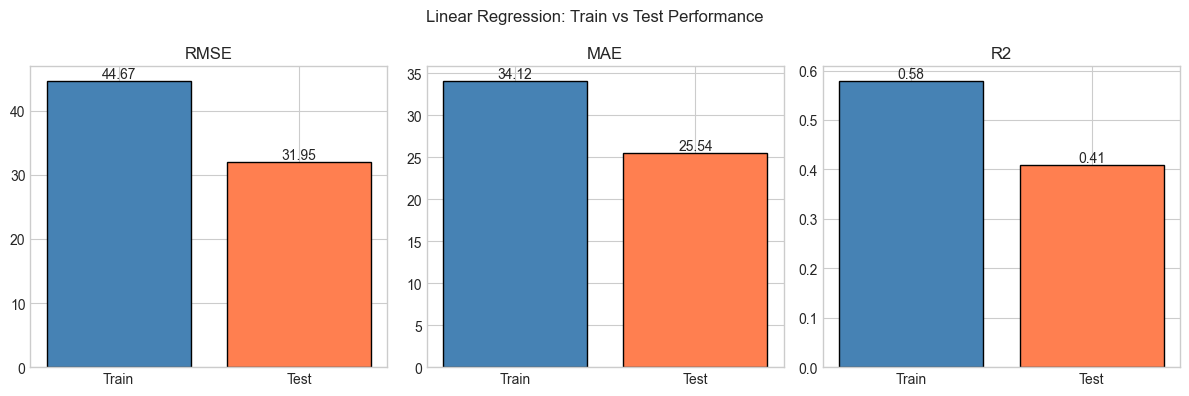

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = ['RMSE', 'MAE', 'R2']
train_vals = [train_results[f'{m} train'] for m in metrics]
test_vals = [test_results[f'{m} test'] for m in metrics]

for i, metric in enumerate(metrics):
    bars = axes[i].bar(['Train', 'Test'], [train_vals[i], test_vals[i]],
                        color=['steelblue', 'coral'], edgecolor='black')
    axes[i].set_title(metric)
    axes[i].bar_label(bars, fmt='%.2f')

plt.suptitle('Linear Regression: Train vs Test Performance')
plt.tight_layout()
plt.show()

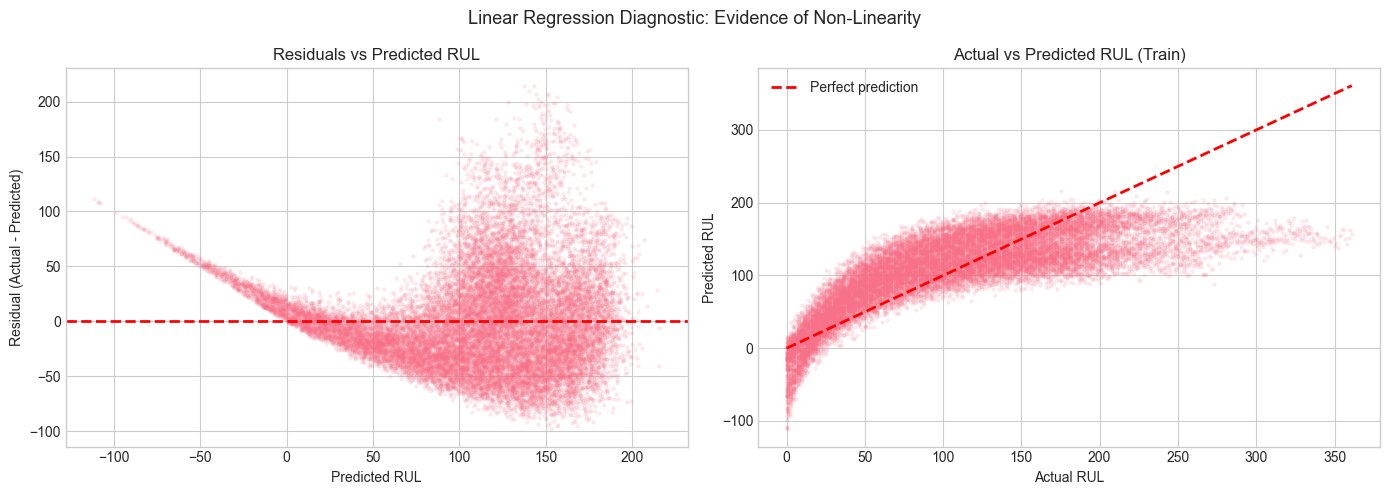

In [15]:
# Residual analysis: is the relationship truly linear?
y_pred_train = model.predict(X)
residuals = y - y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_train, residuals, alpha=0.1, s=5)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted RUL')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted RUL')

# Actual vs Predicted
axes[1].scatter(y, y_pred_train, alpha=0.1, s=5)
axes[1].plot([0, y.max()], [0, y.max()], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
axes[1].set_title('Actual vs Predicted RUL (Train)')
axes[1].legend()

plt.suptitle('Linear Regression Diagnostic: Evidence of Non-Linearity', fontsize=13)
plt.tight_layout()
plt.show()

## RUL Target Refinement

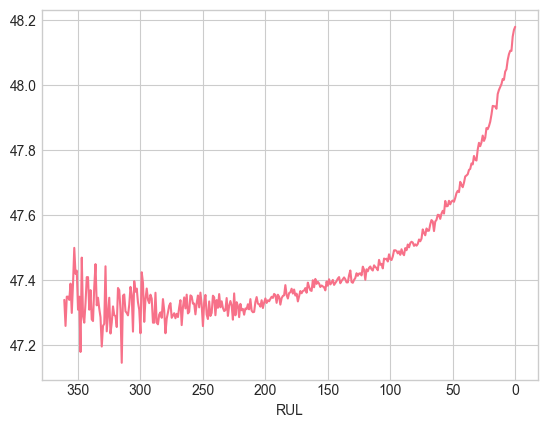

In [16]:
# Sensor 11 vs RUL to visualize non-linear relationship to determine where to cap the RUL
avg_by_rul = df.groupby('rul')['sensor_11'].mean()
avg_by_rul.sort_index(ascending=False).plot()
plt.xlabel('RUL')
plt.gca().invert_xaxis()

To avoid adopting the commonly used cap of 125 cycles arbitrarily, I first identified the degradation onset visually by plotting the cross-engine average of sensor_11 against RUL.

The plot reveals that degradation is not a sudden event but a gradual process. A subtle upward drift begins around RUL 200, followed by a steeper acceleration after RUL 50. This suggests the engine begins deteriorating well before the commonly assumed cap of 125 cycles, though the signal remains relatively gentle in the 125–200 range before becoming pronounced.
Based on this observation, I test four cap values — 125, 150, 175, and 200 — to empirically determine which best focuses the model on the degradation region. A cap of 125 concentrates learning on late-stage deterioration, while a cap of 200 also captures the earlier gradual onset. The value that minimises RMSE on the test set will be adopted for all subsequent modelling steps.

In [17]:
# Selected sensors
feature_cols = [col for col in df.columns if col.startswith('sensor_')]
feature_cols = [col for col in feature_cols if col not in low_var_sensors]  # Remove low variance

X_train = df[feature_cols]
y_train = df['rul']
t = test.groupby('engine_id').last().reset_index()
X_test = t[feature_cols]

In [18]:
cap_values = [125, 150, 175, 200]
cap_results = {}

for cap in cap_values:
    y_train_clipped = y_train.clip(upper=cap)
    y_test_clipped = y_test.clip(upper=cap)
    
    model = LinearRegression()
    model.fit(X_train, y_train_clipped)
    
    results = {}
    results.update(evaluate_model(model, X_train, y_train_clipped, label='train'))
    results.update(evaluate_model(model, X_test, y_test_clipped, label='test'))
    cap_results[cap] = results

# Display results
cap_comparison = pd.DataFrame(cap_results).T
print(cap_comparison)

     RMSE train  MAE train  R2 train  RMSE test  MAE test  R2 test
125       21.49      17.59    0.7340      20.82     16.61   0.7299
150       27.31      22.26    0.7013      23.87     19.12   0.6699
175       32.61      26.66    0.6680      26.82     21.44   0.5834
200       36.75      29.91    0.6404      29.05     23.20   0.5114


In [19]:
# Lock in the best cap
y_train_clipped = y_train.clip(upper=125)
y_test_clipped = y_test.clip(upper=125)

print(y_train_clipped.max())
print(y_test_clipped.max())

125
125


#### Results
Cap at 125 cycles yields the best performance across all metrics on both train and test sets (RMSE: 20.82, R²: 0.73). Performance degrades consistently as the cap increases, suggesting that the gradual drift observed between RUL 200–125 introduces noise rather than useful signal. The steep degradation region below RUL 125 contains the most reliable predictive information, confirming 125 as the optimal cap. All subsequent models will use this value.

## Feature Engineering
### Rolling Statistics

In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Train and evaluate a model on both train and test sets"""
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    return {
        'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE train': mean_absolute_error(y_train, y_pred_train),
        'MAE test': mean_absolute_error(y_test, y_pred_test),
        'R2 train': r2_score(y_train, y_pred_train),
        'R2 test': r2_score(y_test, y_pred_test)
    }

In [21]:
window_sizes = [5, 10, 15]
window_results = {}

for window in window_sizes:
    df_fe = df.copy()
    test_fe = test.copy()
    
    for sensor in feature_cols:
        df_fe[f'{sensor}_roll_mean'] = df_fe.groupby('engine_id')[sensor].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        df_fe[f'{sensor}_roll_std'] = df_fe.groupby('engine_id')[sensor].transform(
            lambda x: x.rolling(window=window, min_periods=1).std().fillna(0)
        )
        test_fe[f'{sensor}_roll_mean'] = test_fe.groupby('engine_id')[sensor].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        test_fe[f'{sensor}_roll_std'] = test_fe.groupby('engine_id')[sensor].transform(
            lambda x: x.rolling(window=window, min_periods=1).std().fillna(0)
        )
    
    features = (feature_cols + 
               [f'{s}_roll_mean' for s in feature_cols] + 
               [f'{s}_roll_std' for s in feature_cols])
    
    X_train_fe = df_fe[features]
    X_test_fe = test_fe.groupby('engine_id').last().reset_index()[features]
    
    model = LinearRegression()
    results = evaluate_model(model, X_train_fe, X_test_fe, y_train_clipped, y_test_clipped)
    window_results[window] = results

# Show comparison
window_comparison = pd.DataFrame(window_results).T
print(window_comparison)

# Lock in best window (15) — df_fe, test_fe, X_train_fe, X_test_fe already set to window=15
print(f"\nBest window: 15")
print(f"X_train_fe shape: {X_train_fe.shape}")
print(f"X_test_fe shape: {X_test_fe.shape}")

    RMSE train  RMSE test  MAE train   MAE test  R2 train   R2 test
5    21.004324  21.025126  17.177779  16.724570  0.745953  0.724725
10   20.953522  20.997489  17.096694  16.704261  0.747180  0.725448
15   20.773154  20.095746  16.910650  15.971823  0.751514  0.748523

Best window: 15
X_train_fe shape: (20631, 42)
X_test_fe shape: (100, 42)


#### Results — Rolling Features with Linear Regression

Adding rolling mean and standard deviation features (window sizes 5, 10, 15) improves train performance slightly as window size increases, with window=15 achieving the best test RMSE of 29.22. However, overall test performance is worse than the capped RUL baseline (RMSE 20.82), and the gap between train and test metrics suggests the model is struggling to generalise.

Rolling features introduce nonlinear temporal patterns that a linear model cannot capture effectively. In the next section tree-based models (Random Forest, XGBoost, LightGBM) will be tried, which can capture these nonlinear relationships. Window size 15 will be carried forward as it showed the best test performance here.

## Random Forest

First, a basic Random Forest with default parameters to have a tree-based baseline.

In [22]:
# First run with defaults to get a baseline before tuning hyperparameters
rf_default = RandomForestRegressor(random_state=42)
results_rf_default = evaluate_model(rf_default, X_train_fe, X_test_fe, y_train_clipped, y_test_clipped)
print("Random Forest (default):")
print(pd.Series(results_rf_default))

Random Forest (default):
RMSE train     3.430021
RMSE test     20.032577
MAE train      2.217053
MAE test      14.077200
R2 train       0.993225
R2 test        0.750101
dtype: float64


In [23]:
configs = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4},
    {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 4},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 8},
]

for config in configs:
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, **config)
    results = evaluate_model(rf, X_train_fe, X_test_fe, y_train_clipped, y_test_clipped)
    print(f"\nParams: {config}")
    for metric, value in results.items():
        print(f"{metric:<15}: {value:.4f}")


Params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4}
RMSE train     : 12.1844
RMSE test      : 19.9309
MAE train      : 8.1671
MAE test       : 14.0159
R2 train       : 0.9145
R2 test        : 0.7526

Params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 4}
RMSE train     : 6.9098
RMSE test      : 20.0684
MAE train      : 4.4867
MAE test       : 14.1062
R2 train       : 0.9725
R2 test        : 0.7492

Params: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 8}
RMSE train     : 7.4534
RMSE test      : 20.2510
MAE train      : 5.0156
MAE test       : 14.2957
R2 train       : 0.9680
R2 test        : 0.7446


In [24]:
best_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10, 
    min_samples_leaf=4,
    random_state=42, 
    n_jobs=-1
)
best_rf.fit(X_train_fe, y_train_clipped)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

The default model shows strong test performance (RMSE: 20.03, R²: 0.75) but significant overfitting; train RMSE of 3.4 vs test RMSE of 20.0 suggests the unconstrained trees are memorising the training data. We tested three regularised configurations by constraining *max_depth, min_samples_split, and min_samples_leaf* to limit tree complexity.

Config 1 (max_depth=10, min_samples_split=10, min_samples_leaf=4) achieves the best result — test RMSE of 19.93 with a healthier train/test gap (12.18 vs 19.93), confirming that regularisation improved generalisation without sacrificing test performance. This configuration is carried forward as the best Random Forest model.

## XGBoost

In [25]:
# First run default to see baseline
xgb_default = XGBRegressor(random_state=42, n_jobs=-1)
results_xgb_default = evaluate_model(xgb_default, X_train_fe, X_test_fe, y_train_clipped, y_test_clipped)
print("XGBoost (default):")
for metric, value in results_xgb_default.items():
    print(f"{metric:<15}: {value:.4f}")

XGBoost (default):
RMSE train     : 5.9342
RMSE test      : 19.2225
MAE train      : 4.2729
MAE test       : 14.3141
R2 train       : 0.9797
R2 test        : 0.7699


In [26]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_fe, y_train_clipped, 
    test_size=0.2, 
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"\nBest iteration: {xgb.best_iteration}")

y_pred_train = xgb.predict(X_train_fe)
y_pred_test = xgb.predict(X_test_fe)

results_xgb = {
    'RMSE train': np.sqrt(mean_squared_error(y_train_clipped, y_pred_train)),
    'RMSE test': np.sqrt(mean_squared_error(y_test_clipped, y_pred_test)),
    'MAE train': mean_absolute_error(y_train_clipped, y_pred_train),
    'MAE test': mean_absolute_error(y_test_clipped, y_pred_test),
    'R2 train': r2_score(y_train_clipped, y_pred_train),
    'R2 test': r2_score(y_test_clipped, y_pred_test)
}

for metric, value in results_xgb.items():
    print(f"{metric:<15}: {value:.4f}")

[0]	validation_0-rmse:39.65459
[100]	validation_0-rmse:16.73366
[200]	validation_0-rmse:15.63401
[300]	validation_0-rmse:14.89003
[400]	validation_0-rmse:14.38687
[500]	validation_0-rmse:13.92030
[600]	validation_0-rmse:13.55433
[700]	validation_0-rmse:13.22577
[800]	validation_0-rmse:12.93390
[900]	validation_0-rmse:12.67827
[999]	validation_0-rmse:12.46094

Best iteration: 998
RMSE train     : 9.5858
RMSE test      : 18.4246
MAE train      : 6.8406
MAE test       : 13.6497
R2 train       : 0.9471
R2 test        : 0.7886


In [27]:
configs = [
    {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7},
]

for config in configs:
    xgb = XGBRegressor(random_state=42, n_jobs=-1, **config)
    xgb.fit(X_train_fe, y_train_clipped)
    
    y_pred_train = xgb.predict(X_train_fe)
    y_pred_test = xgb.predict(X_test_fe)
    
    results = {
        'RMSE train': np.sqrt(mean_squared_error(y_train_clipped, y_pred_train)),
        'RMSE test': np.sqrt(mean_squared_error(y_test_clipped, y_pred_test)),
        'MAE test': mean_absolute_error(y_test_clipped, y_pred_test),
        'R2 test': r2_score(y_test_clipped, y_pred_test)
    }
    print(f"\nParams: {config}")
    for metric, value in results.items():
        print(f"{metric:<15}: {value:.4f}")


Params: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE train     : 12.6394
RMSE test      : 17.8589
MAE test       : 13.5603
R2 test        : 0.8014

Params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE train     : 9.2594
RMSE test      : 17.7547
MAE test       : 13.2741
R2 test        : 0.8037

Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7}
RMSE train     : 13.9542
RMSE test      : 17.3285
MAE test       : 12.9332
R2 test        : 0.8130


#### XGBoost Hyperparameter Tuning

The default XGBoost model showed clear overfitting (train RMSE 5.93 vs test RMSE 19.22), so tuning focused on regularisation. Two rounds were conducted.

**Round 1 -** Early stopping with regularisation: An initial attempt used early stopping with n_estimators=1000, max_depth=4, learning_rate=0.05, L1/L2 regularisation (reg_alpha=0.1, reg_lambda=1.0), and a held-out validation set. Early stopping failed to trigger — the validation RMSE continued decreasing through all 1000 iterations — suggesting the learning rate was too slow relative to the number of estimators. Test RMSE was 18.42.

**Round 2 —** Manual configuration search: Early stopping was not used and instead opted for a structured manual search. Increasing the learning rate to 0.1 and reducing subsample and colsample_bytree to 0.7 proved more effective. The best configuration *— n_estimators=300, max_depth=3, learning_rate=0.1, subsample=0.7, colsample_bytree=0.7 —* achieved test RMSE of 17.33 (R²: 0.81).

Shallower trees (max_depth=3) consistently outperformed deeper ones across all configurations, confirming that tree complexity was the main driver of overfitting.

## LightGBM

In [28]:
# Baseline LightGBM with defaults
lgbm_default = LGBMRegressor(random_state=42, n_jobs=-1)
lgbm_default.fit(X_train_fe, y_train_clipped)

y_pred_train = lgbm_default.predict(X_train_fe)
y_pred_test = lgbm_default.predict(X_test_fe)

results_lgbm_default = {
    'RMSE train': np.sqrt(mean_squared_error(y_train_clipped, y_pred_train)),
    'RMSE test': np.sqrt(mean_squared_error(y_test_clipped, y_pred_test)),
    'MAE train': mean_absolute_error(y_train_clipped, y_pred_train),
    'MAE test': mean_absolute_error(y_test_clipped, y_pred_test),
    'R2 train': r2_score(y_train_clipped, y_pred_train),
    'R2 test': r2_score(y_test_clipped, y_pred_test)
}

print("LightGBM (default):")
for metric, value in results_lgbm_default.items():
    print(f"{metric:<15}: {value:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9732
[LightGBM] [Info] Number of data points in the train set: 20631, number of used features: 42
[LightGBM] [Info] Start training from score 86.829286
LightGBM (default):
RMSE train     : 10.5069
RMSE test      : 18.9828
MAE train      : 7.6825
MAE test       : 13.6829
R2 train       : 0.9364
R2 test        : 0.7756


In [29]:
configs = [
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7},
]

for config in configs:
    lgbm = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **config)
    lgbm.fit(X_train_fe, y_train_clipped)
    
    y_pred_train = lgbm.predict(X_train_fe)
    y_pred_test = lgbm.predict(X_test_fe)
    
    results = {
        'RMSE train': np.sqrt(mean_squared_error(y_train_clipped, y_pred_train)),
        'RMSE test': np.sqrt(mean_squared_error(y_test_clipped, y_pred_test)),
        'MAE test': mean_absolute_error(y_test_clipped, y_pred_test),
        'R2 test': r2_score(y_test_clipped, y_pred_test)
    }
    print(f"\nParams: {config}")
    for metric, value in results.items():
        print(f"{metric:<15}: {value:.4f}")


Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7}
RMSE train     : 14.1736
RMSE test      : 17.9919
MAE test       : 13.1512
R2 test        : 0.7984

Params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7}
RMSE train     : 11.5354
RMSE test      : 18.4592
MAE test       : 13.6677
R2 test        : 0.7878

Params: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7}
RMSE train     : 12.9073
RMSE test      : 18.1199
MAE test       : 13.3338
R2 test        : 0.7955

Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7}
RMSE train     : 15.2977
RMSE test      : 18.3407
MAE test       : 13.2401
R2 test        : 0.7905


In [30]:
best_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train_fe, y_train_clipped)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### LightGBM

The default model achieves test RMSE of 18.98 (R²: 0.78), comparable to XGBoost's default.
Tuning followed the same logic as XGBoost; shallow trees, moderate subsampling, and a learning rate of 0.1. The best configuration (n_estimators=300, max_depth=3, learning_rate=0.1, subsample=0.7, colsample_bytree=0.7) achieves test RMSE of 17.99 (R²: 0.80), an improvement over the default but still short of the tuned XGBoost result.

## Model Comparison Summary

| Model | RMSE Test | MAE Test | R2 Test |
|-------|-----------|----------|---------|
| Linear Regression (baseline) | 20.82 | 16.61 | 0.73 |
| Linear Regression (capped + rolling) | 20.09 | 15.97 | 0.75 |
| Random Forest (tuned) | 19.93 | 14.02 | 0.75 |
| LightGBM (tuned) | 17.99 | 13.15 | 0.80 |
| **XGBoost (tuned)** | **17.33** | **12.93** | **0.81** |

XGBoost with the tuned configuration is selected as the final model for explainability analysis. The progression from baseline to final model represents a 16.8% reduction in RMSE, achieved through three successive improvements: target capping, rolling feature engineering, and gradient boosting with regularisation.

## SHAP Analysis

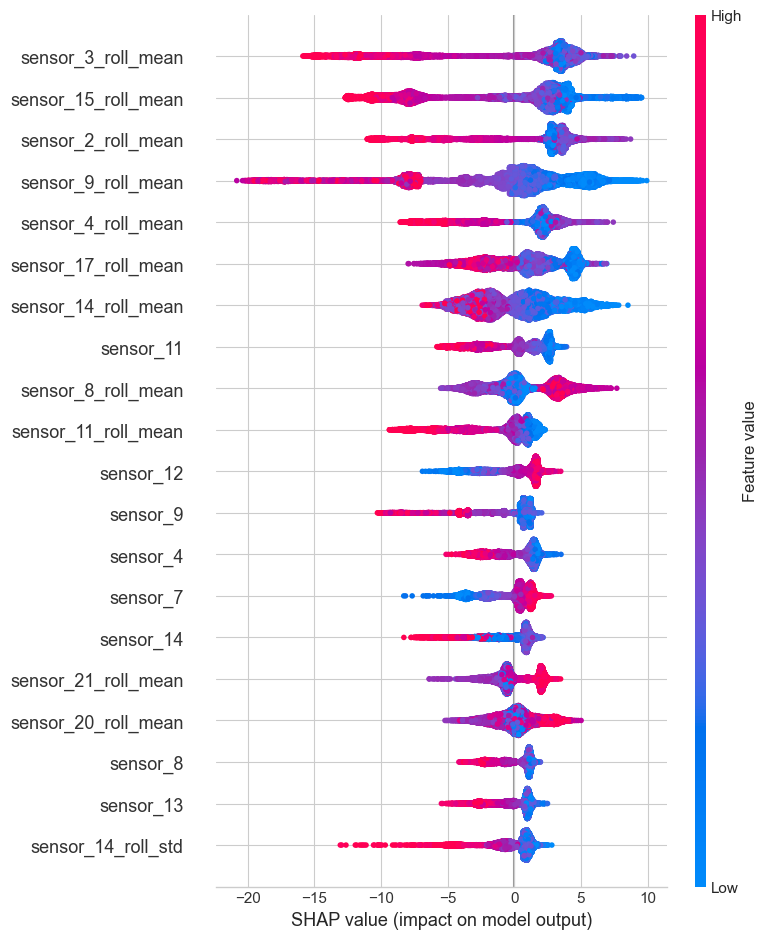

In [31]:
# Compute SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_fe)

# 1. Summary plot — overview of all features
shap.summary_plot(shap_values, X_train_fe, max_display=20)

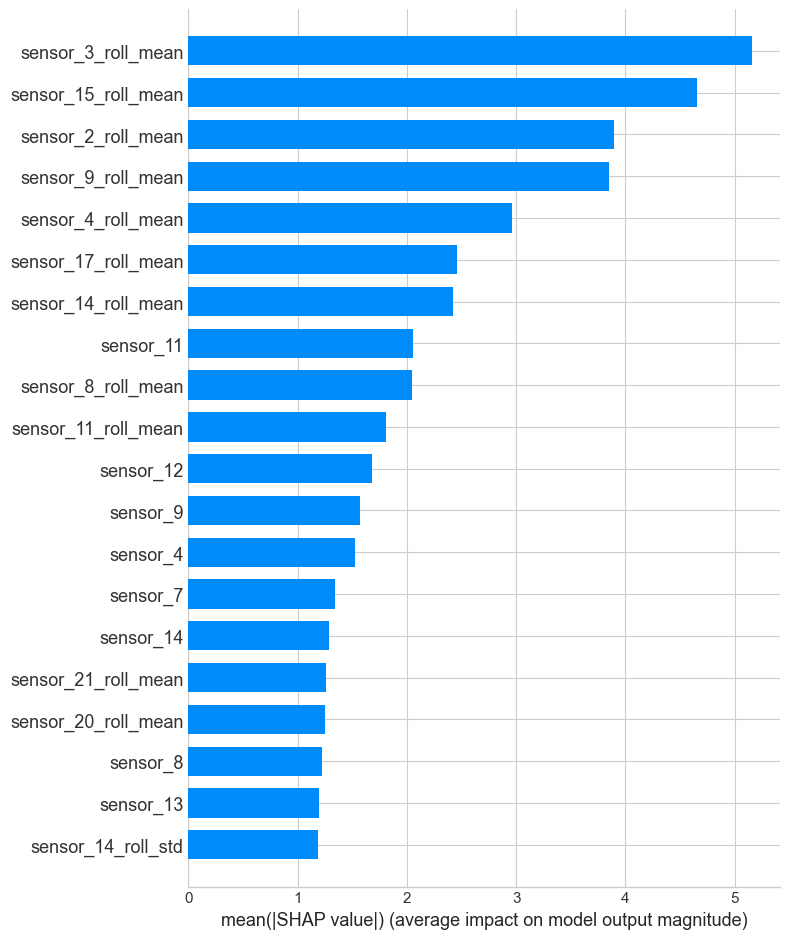

In [32]:
shap.summary_plot(shap_values, X_train_fe, 
                  plot_type='bar', 
                  max_display=20)

### SHAP Bar Plot — Global Feature Importance
The bar plot summarises global feature importance by showing the mean absolute SHAP value for each feature across all training samples, a measure of average impact magnitude regardless of direction.

Several things stand out:

**The top four features** — sensor_3_roll_mean, sensor_15_roll_mean, sensor_2_roll_mean, and sensor_9_roll_mean — have roughly double the impact of all features below sensor_4_roll_mean, suggesting these four sensors carry the majority of the predictive signal for engine degradation.

**Rolling means dominate the ranking** — 7 of the top 10 features are _roll_mean features, confirming that recent sensor trend is more informative than instantaneous readings.

**sensor_14_roll_std** is the only standard deviation feature in the top 20, suggesting that sensor volatility contributes less predictive signal than trend for this dataset. The rolling std features were still worth including, but trend clearly dominates. The bottom 10 features show very similar and low impact magnitudes, indicating diminishing returns. In a production setting these could potentially be pruned without meaningful performance loss.

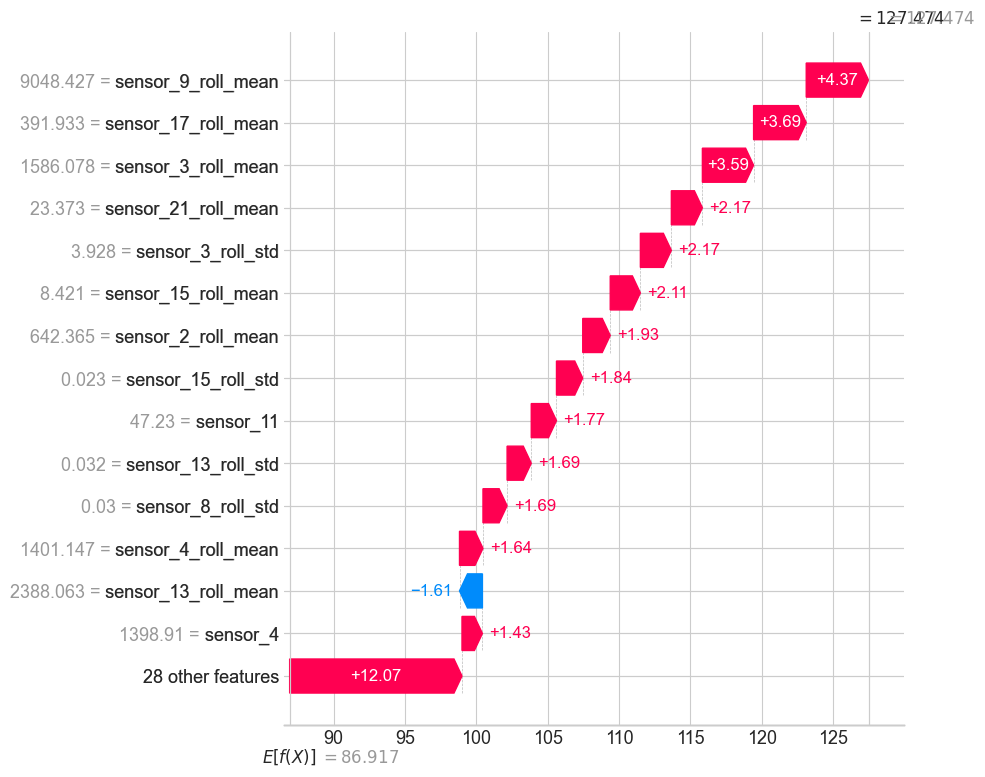

In [33]:
# Pick engine index 0 from test set
sample_idx = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_fe.iloc[sample_idx],
        feature_names=X_test_fe.columns.tolist()
    ),
    max_display=15
)

### SHAP Waterfall Plot — Single Engine Prediction

The waterfall plot shows how the model arrived at its RUL prediction for one specific engine. Starting from the baseline prediction of 86.9 cycles (the dataset average), each feature either increases or decreases the final prediction.

For this engine the model predicts RUL = 127.47 cycles (well above the baseline). Nearly all features push the prediction upward, indicating the engine's sensor readings are characteristic of a healthy machine with substantial remaining life. The dominant positive contributors are sensor_9_roll_mean (+4.37), sensor_17_roll_mean (+3.69), and sensor_3_roll_mean (+3.59). The only notable negative contributor is sensor_13_roll_mean (-1.61), which slightly pulls the prediction toward earlier failure.

This individual-level explanation demonstrates how the model reasons about a specific engine, not just which features matter globally, but how their current values interact to produce a concrete maintenance recommendation.

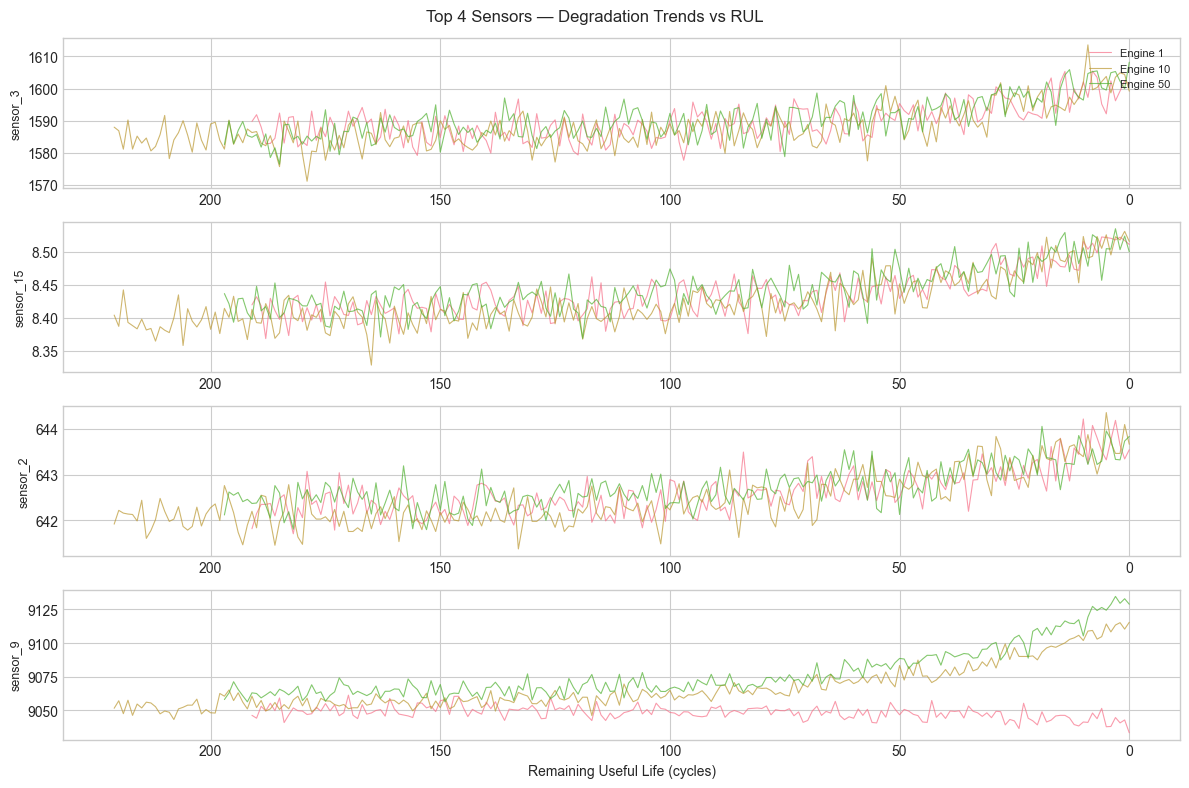

In [35]:
# Images to add to README in Github
fig, axes = plt.subplots(4, 1, figsize=(12, 8), squeeze=False)

top_sensors = ['sensor_3', 'sensor_15', 'sensor_2', 'sensor_9']
sample_engines = [1, 10, 50]

for i, sensor in enumerate(top_sensors):
    for engine in sample_engines:
        engine_data = df[df['engine_id'] == engine]
        axes[i][0].plot(engine_data['rul'], engine_data[sensor],
                        label=f'Engine {engine}', alpha=0.7, linewidth=0.8)
    axes[i][0].set_ylabel(sensor, fontsize=9)
    axes[i][0].invert_xaxis()
    if i == 0:
        axes[i][0].legend(loc='upper right', fontsize=8)

axes[-1][0].set_xlabel('Remaining Useful Life (cycles)')
plt.suptitle('Top 4 Sensors — Degradation Trends vs RUL', fontsize=12)
plt.tight_layout()
plt.savefig('../images/sensor_trends.png', dpi=150, bbox_inches='tight')
plt.show()

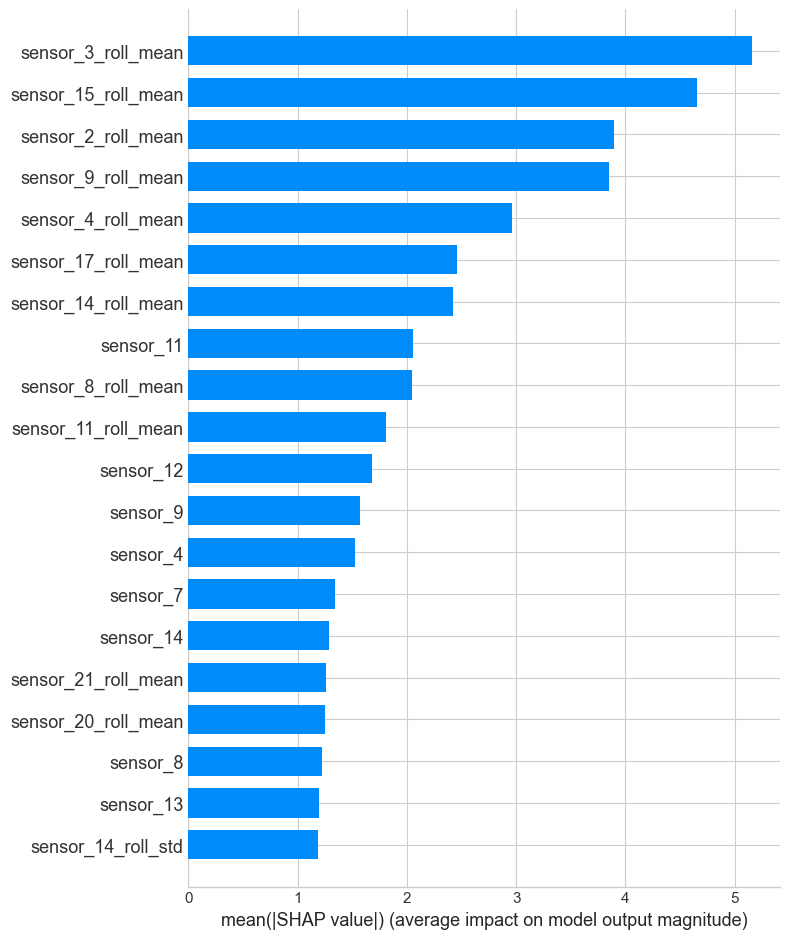

In [37]:
fig = plt.figure()
shap.summary_plot(shap_values, X_train_fe, plot_type='bar', max_display=20, show=False)
plt.savefig('../images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()